In [1]:
import numpy as np
import xarray as xr
import cf_xarray as cfxr
import cf_xarray.units
import pint_xarray
import pint
from pint import application_registry as ureg
import matplotlib.pyplot as plt
import intake
import seaborn as sns, matplotlib.pyplot as plt
from os import environ
import warnings
environ["PYTHONWARNINGS"] = "ignore"

In [2]:
from dask_jobqueue import SLURMCluster
from dask.distributed import Client
cluster = SLURMCluster(
    memory="100GB",
    processes=8,
    cores=8,
    walltime="01:00:00",
    queue="dcgp_usr_prod",
    account="ICT26_ESP",
    interface="ib0",
    env_extra=[
        "export OMP_NUM_THREADS=1",
        "export MKL_NUM_THREADS=1",
        "export NUMBA_NUM_THREADS=1",
    ],
    job_extra=[
        "--nodes=1",
        "--ntasks-per-node=8",
        "--hint=nomultithread",
    ],
    log_directory="logs/"
)

cluster.scale(16)
client = Client(cluster)

client

/leonardo/home/userexternal/ntilinin/.venvs/ocean2/lib/python3.11/site-packages/dask_jobqueue/core.py:266: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/leonardo/home/userexternal/ntilinin/.venvs/ocean2/lib/python3.11/site-packages/dask_jobqueue/core.py:285: FutureWarning: env_extra has been renamed to job_script_prologue. You are still using it (even if only set to []; please also check config files). If you did not set job_script_prologue yet, env_extra will be respected for now, but it will be removed in a future release. If you already set job_script_prologue, env_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarnin

Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: http://10.128.0.7:8787/status,
Dashboard: http://10.128.0.7:8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://10.128.0.7:42299,Workers: 0
Dashboard: http://10.128.0.7:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [3]:
%%time 

experiment = 'AccessOm2IAF'

CPU times: user 10 μs, sys: 0 ns, total: 10 μs
Wall time: 19.1 μs


In [4]:
%%time 
CATALOG_sp = "/leonardo_scratch/fast/ICT26_ESP/ntilinin/access-om2-catalog/AccessOm2IAF_SPEEDY.json"

catalog_sp = intake.open_esm_datastore(
    CATALOG_sp,
    columns_with_iterables=[
        "variable",
        "variable_long_name",
        "variable_standard_name",
        "variable_cell_methods",
        "variable_units",
    ]
)

CATALOG_jr = "/leonardo_scratch/fast/ICT26_ESP/ntilinin/access-om2-catalog/AccessOm2IAF_JRA55.json"

catalog_jr = intake.open_esm_datastore(
    CATALOG_jr,
    columns_with_iterables=[
        "variable",
        "variable_long_name",
        "variable_standard_name",
        "variable_cell_methods",
        "variable_units",
    ]
)

CPU times: user 18.1 s, sys: 1.5 s, total: 19.6 s
Wall time: 22.5 s


In [5]:
variable = "net_sfc_heating"

ds_sp = catalog_sp.search(
    variable=variable,
    frequency="1mon"
).to_dask()

ds_jr = catalog_jr.search(
    variable=variable,
    frequency="1mon"
).to_dask()

sst_sp = ds_sp[variable]
sst_jr = ds_jr[variable]

In [6]:
sst_jr.attrs

{'long_name': 'surface ocean heat flux coming through coupler and mass transfer',
 'units': 'Watts/m^2',
 'valid_range': array([-10000.,  10000.], dtype=float32),
 'cell_methods': 'time: mean',
 'time_avg_info': 'average_T1,average_T2,average_DT'}

In [7]:
GRID_PATH = "/leonardo_scratch/fast/ICT26_ESP_0/ntilinin/access-om2/archive/1deg_speedy_iaf/output000/ocean"

area = xr.open_dataset(
    f"{GRID_PATH}/ocean-2d-area_t.nc"
)["area_t"]

area

<xarray.DataArray 'area_t' (yt_ocean: 300, xt_ocean: 360)> Size: 432kB
[108000 values with dtype=float32]
Coordinates:
  * yt_ocean  (yt_ocean) float64 2kB -77.88 -77.63 -77.38 ... 88.87 89.32 89.77
  * xt_ocean  (xt_ocean) float64 3kB -279.5 -278.5 -277.5 ... 77.5 78.5 79.5
Attributes:
    long_name:     tracer cell area
    units:         m^2
    valid_range:   [0.e+00 1.e+15]
    cell_methods:  time: point

In [9]:
# Ocean mask + area weights
weights = area.where(sst_sp.isel(time=0).notnull(), 0)

In [10]:
# # Global area-weighted annual mean SST
sst_ann_sp=sst_sp.groupby("time.year").mean("time")
sst_global_sp=sst_ann_sp.weighted(weights).mean(("yt_ocean","xt_ocean")).compute(scheduler="single-threaded")
sst_ann_jr=sst_jr.groupby("time.year").mean("time")
sst_global_jr=sst_ann_jr.weighted(weights).mean(("yt_ocean","xt_ocean")).compute(scheduler="single-threaded")

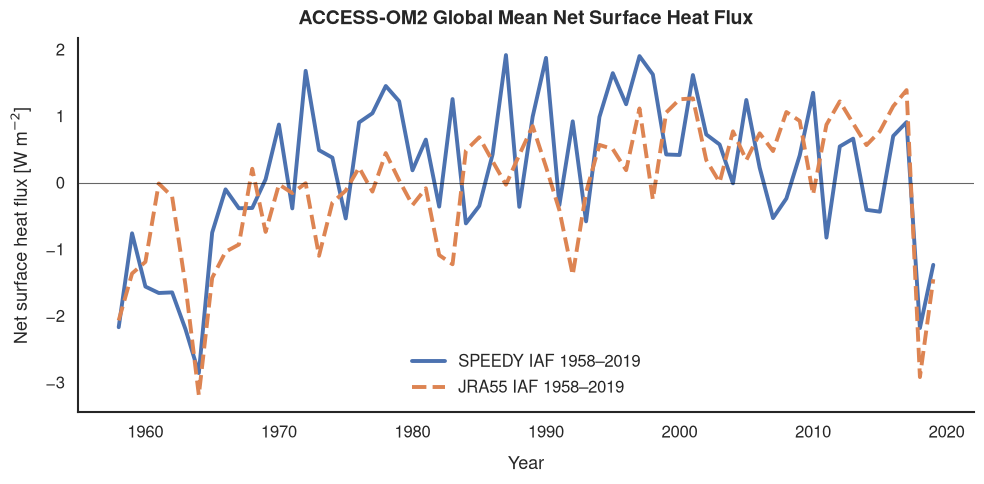

In [11]:
import seaborn as sns, matplotlib.pyplot as plt

sns.set_theme(style="white")
plt.rcParams.update({"font.family":"Nimbus Sans"})

fig,ax=plt.subplots(figsize=(10,5))

ax.plot(sst_global_sp.year,sst_global_sp,linewidth=2.8,label="SPEEDY IAF 1958–2019")
ax.plot(sst_global_jr.year,sst_global_jr,linewidth=2.8,linestyle="--",label="JRA55 IAF 1958–2019")

ax.axhline(0,color="black",linewidth=0.8,alpha=0.6)
ax.set_title("ACCESS-OM2 Global Mean Net Surface Heat Flux",fontsize=14,pad=10,fontweight="bold")

ax.set_ylabel("Net surface heat flux [W m$^{-2}$]",fontsize=13,labelpad=10); ax.set_xlabel("Year",fontsize=13,labelpad=10)
ax.tick_params(axis="both",labelsize=12,width=1.2)

ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5); ax.spines["bottom"].set_linewidth(1.5)

ax.legend(frameon=False,fontsize=12)
fig.tight_layout()

plt.savefig("figures/access_om2_global_mean_sflux_df_IAF.png",
            dpi=300, bbox_inches="tight")
plt.show()

In [12]:
hu_year_sp=((sst_ann_sp*weights).sum(("yt_ocean","xt_ocean"))*365*24*3600/1e21).compute(scheduler="single-threaded")
hu_year_jr=((sst_ann_jr*weights).sum(("yt_ocean","xt_ocean"))*365*24*3600/1e21).compute(scheduler="single-threaded")

hu_cum_sp=hu_year_sp.cumsum("year")
hu_cum_jr=hu_year_jr.cumsum("year")

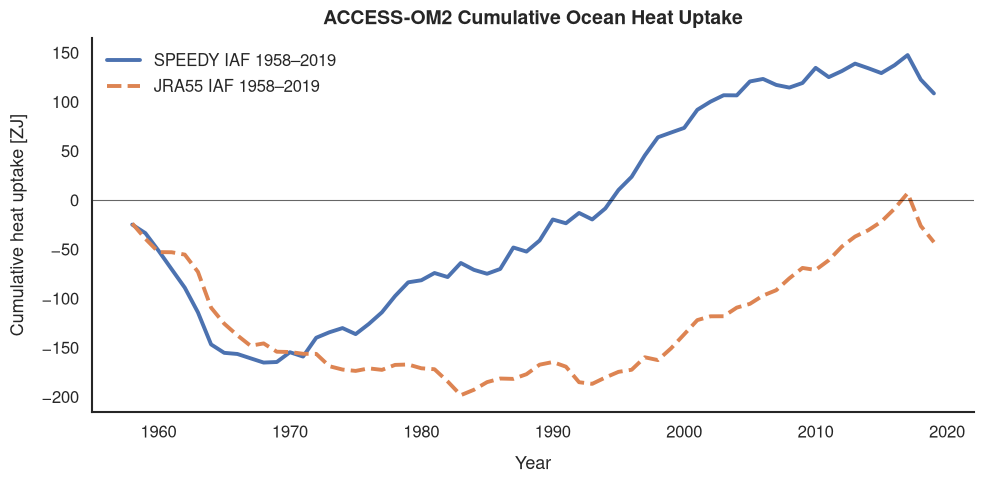

In [13]:
sns.set_theme(style="white")
plt.rcParams.update({"font.family":"Nimbus Sans"})

fig,ax=plt.subplots(figsize=(10,5))

ax.plot(hu_cum_sp.year,hu_cum_sp,linewidth=2.8,label="SPEEDY IAF 1958–2019")
ax.plot(hu_cum_jr.year,hu_cum_jr,linewidth=2.8,linestyle="--",label="JRA55 IAF 1958–2019")

ax.axhline(0,color="black",linewidth=0.8,alpha=0.6)

ax.set_title("ACCESS-OM2 Cumulative Ocean Heat Uptake",fontsize=14,pad=10,fontweight="bold")
ax.set_ylabel("Cumulative heat uptake [ZJ]",fontsize=13,labelpad=10); ax.set_xlabel("Year",fontsize=13,labelpad=10)

ax.tick_params(axis="both",labelsize=12,width=1.2)

ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5); ax.spines["bottom"].set_linewidth(1.5)

ax.legend(frameon=False,fontsize=12)
fig.tight_layout()
plt.savefig("figures/access_om2_global_mean_cum_heatuptake_df_IAF.png",
            dpi=300, bbox_inches="tight")
plt.show()

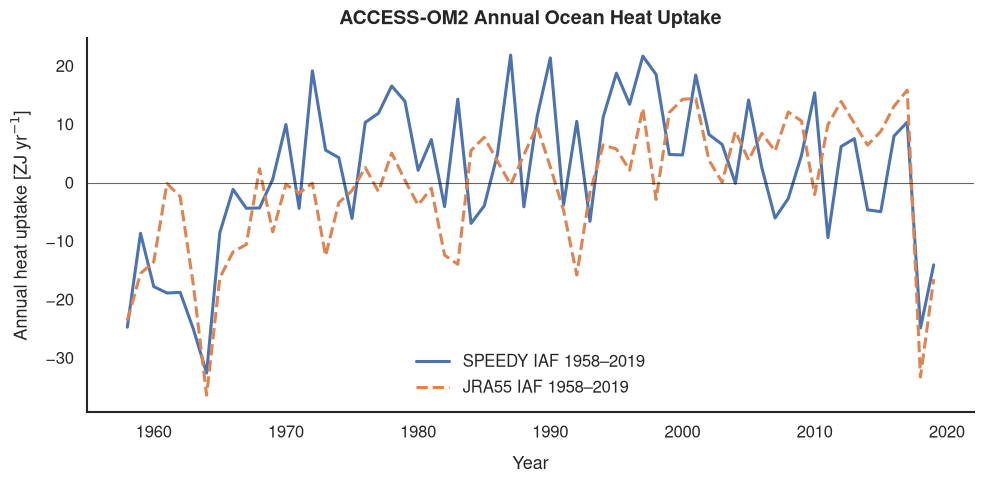

In [14]:
sns.set_theme(style="white")
plt.rcParams.update({"font.family":"Nimbus Sans"})

fig,ax=plt.subplots(figsize=(10,5))
ax.plot(hu_year_sp.year,hu_year_sp,linewidth=2.2,label="SPEEDY IAF 1958–2019")
ax.plot(hu_year_jr.year,hu_year_jr,linewidth=2.2,linestyle="--",label="JRA55 IAF 1958–2019")
ax.axhline(0,color="black",linewidth=0.8,alpha=0.6)

ax.set_title("ACCESS-OM2 Annual Ocean Heat Uptake",fontsize=14,pad=10,fontweight="bold")
ax.set_ylabel("Annual heat uptake [ZJ yr$^{-1}$]",fontsize=13,labelpad=10)
ax.set_xlabel("Year",fontsize=13,labelpad=10)

ax.tick_params(axis="both",labelsize=12,width=1.2)

ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5); ax.spines["bottom"].set_linewidth(1.5)

ax.legend(frameon=False,fontsize=12)
fig.tight_layout()
plt.savefig("figures/access_om2_global_mean_ann_heatuptake_df_IAF.png",
            dpi=300, bbox_inches="tight")
plt.show()

In [15]:
client.close()
cluster.close()

/leonardo/home/userexternal/ntilinin/.venvs/ocean2/lib/python3.11/site-packages/dask_jobqueue/core.py:266: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/leonardo/home/userexternal/ntilinin/.venvs/ocean2/lib/python3.11/site-packages/dask_jobqueue/core.py:285: FutureWarning: env_extra has been renamed to job_script_prologue. You are still using it (even if only set to []; please also check config files). If you did not set job_script_prologue yet, env_extra will be respected for now, but it will be removed in a future release. If you already set job_script_prologue, env_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarnin

: 